In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

# Optional: SHAP
!pip install shap
import shap

In [13]:
# ============================================================
# STEP 3.1 - DATA CLEANING & PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np

# Load dataset
# Load directly from a URL (no download needed)
#url = "https://archive.ics.uci.edu/static/public/45/data.csv"
# Load directly from github - contains the same data as data from the source
url = "https://raw.githubusercontent.com/eschenry/Heart-Disease-ML/refs/heads/main/data/data.csv" 
df = pd.read_csv(url)

# ------------------------------------------------------------
# 3.1.1 Initial Data Quality Assessment
# ------------------------------------------------------------

print("Initial Dataset Shape:", df.shape)

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3.1.2 Standardize Missing Values
# ------------------------------------------------------------

# UCI datasets frequently encode missing values as '?'
df = df.replace("?", np.nan)

# ------------------------------------------------------------
# 3.1.3 Convert Columns to Numeric
# ------------------------------------------------------------

# Convert values to numeric wherever possible
df = df.apply(lambda col: pd.to_numeric(col, errors='coerce'))

# ------------------------------------------------------------
# 3.1.4 Remove Duplicate Records
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates()

print("\nDuplicates Removed:", duplicate_count)
print("Dataset Shape After Duplicate Removal:", df.shape)

# ------------------------------------------------------------
# 3.1.5 Missing Value Imputation
# ------------------------------------------------------------

print("\nMissing Values Before Imputation:")
print(df.isnull().sum())

# Mode imputation for categorical-like variables
categorical_cols = ['ca', 'thal']

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Median imputation for remaining numeric columns
numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Imputation:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3.1.6 Outlier Detection & Treatment (IQR Method)
# ------------------------------------------------------------

num_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

outlier_report = []

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = (
        ((df[col] < lower_bound) |
         (df[col] > upper_bound))
    ).sum()

    # IQR-based capping (winsorization)
    df[col] = np.clip(
        df[col],
        lower_bound,
        upper_bound
    )

    outlier_report.append([
        col,
        round(lower_bound, 2),
        round(upper_bound, 2),
        outliers_before
    ])

outlier_report = pd.DataFrame(
    outlier_report,
    columns=[
        "Feature",
        "Lower Bound",
        "Upper Bound",
        "Outliers Capped"
    ]
)

print("\nOutlier Treatment Summary")
print(outlier_report)

# ------------------------------------------------------------
# 3.1.7 Final Validation
# ------------------------------------------------------------

print("\nFinal Dataset Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nData Types:")
print(df.dtypes)

print("\nCleaning Completed Successfully")

Initial Dataset Shape: (303, 14)

Duplicate Records:
0

Missing Values Before Cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Duplicates Removed: 0
Dataset Shape After Duplicate Removal: (303, 14)

Missing Values Before Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Missing Values After Imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Outlier Treatment Summary
    Feature  Lower Bound  Upper Bound  Outliers Capped
0       age        28.50        80.50                0
1  tres

29 77
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
age_bin     0
dtype: int64


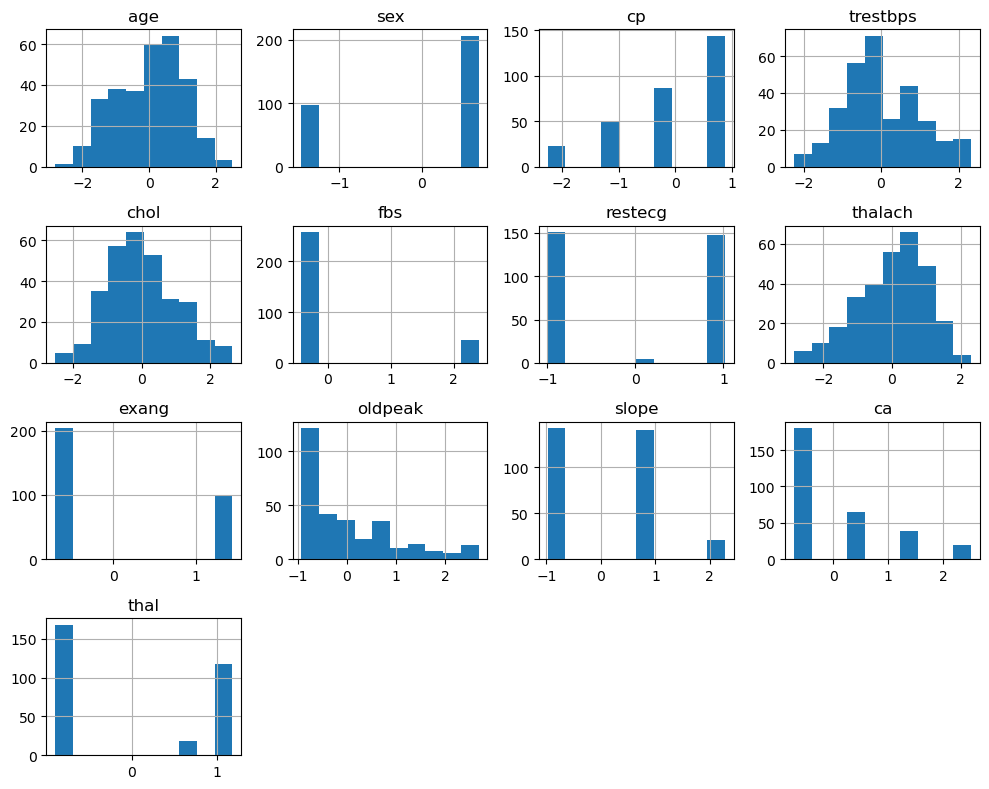

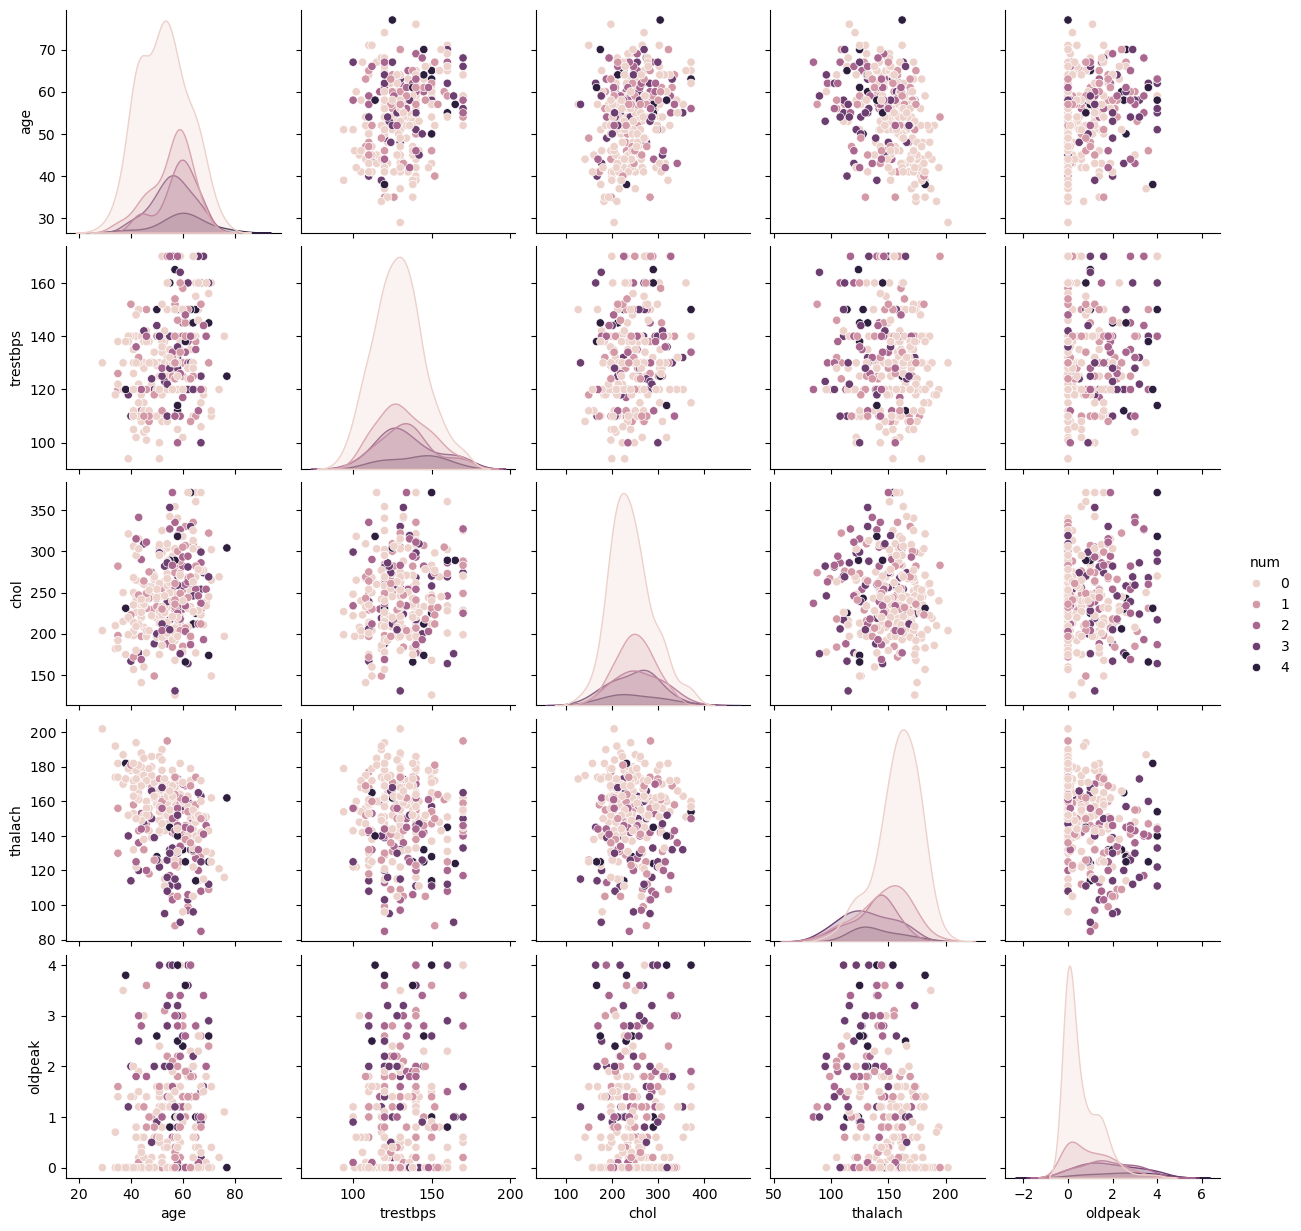

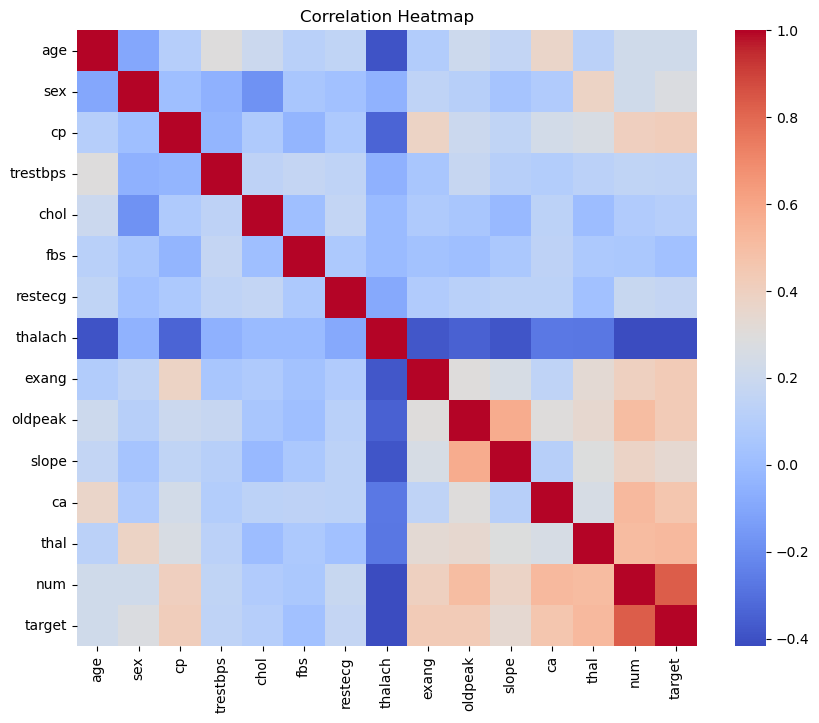

In [14]:

# ------------------------------------------------------------
# Step 3.2 Feature engineering: scaling, encoding, binning, domain features
# ------------------------------------------------------------
# 

# ------------------------------------------------------------
# Setting for 3.2.1. Separate target
# ------------------------------------------------------------

#y = df['num']
#X = df.drop('num', axis=1)
# Fix "3.2.1. Separate target" = Fix Step 4 - Recreate X and y correctly
df['target'] = (df['num'] > 0).astype(int)
y = df['target']
X = df.drop(['num','target'], axis=1)

# Fix Step 5 — Recompute numeric columns since earlier num_cols list may be missing some numeric fields.
num_cols = X.select_dtypes(include=['float64','int64']).columns.tolist()


# ------------------------------------------------------------
# Step 3.2.2 Scaling numeric features
# ------------------------------------------------------------

# Fix Step 6 — Scale safely == # Step 3.2.2 Scaling numeric features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# Step 7 — Fix age binning NaNs: bin range must cover all ages. Check min/max:
print(df['age'].min(), df['age'].max())

#then bin safely:
# ------------------------------------------------------------
# Step 3.2.3 Binning (example: age groups)
# ------------------------------------------------------------

X_scaled['age_bin'] = pd.cut( 
    df['age'],
    bins=[20, 40, 50, 60, 80],
    labels=['20-40','40-50','50-60','60+'],
    include_lowest=True
).astype('category').cat.codes

# Fix Step 8 — Verify no NaNs remain
print(X_scaled.isna().sum())
# If all zeros → proceed.

# ------------------------------------------------------------
# Step 3.2.4 Domain-derived feature (example: risk index)
# ------------------------------------------------------------
X_scaled['risk_index'] = (
    0.3 * df['trestbps'] +
    0.3 * df['chol'] -
    0.4 * df['thalach'] +
    0.5 * df['oldpeak']
)

# ------------------------------------------------------------
# Step 3.3 Applied EDA: distributions, relationships, clustering tendency
# ------------------------------------------------------------
# ------------------------------------------------------------
# 3.3.1 Distributions
# ------------------------------------------------------------
X_scaled[num_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# 3.3.2 Relationships (pairplot subset)  #target == num
sns.pairplot(df[['age','trestbps','chol','thalach','oldpeak','num']],
             hue='num')
plt.show()

# ------------------------------------------------------------
# 3.3.3 Correlation matrix
# ------------------------------------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

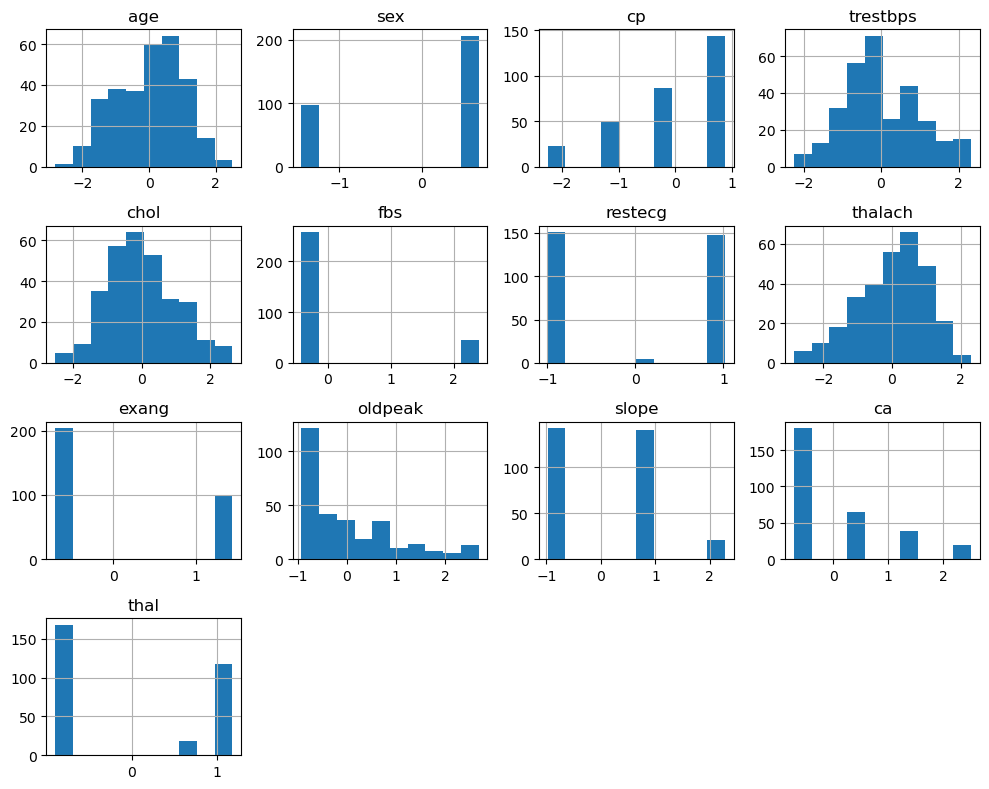

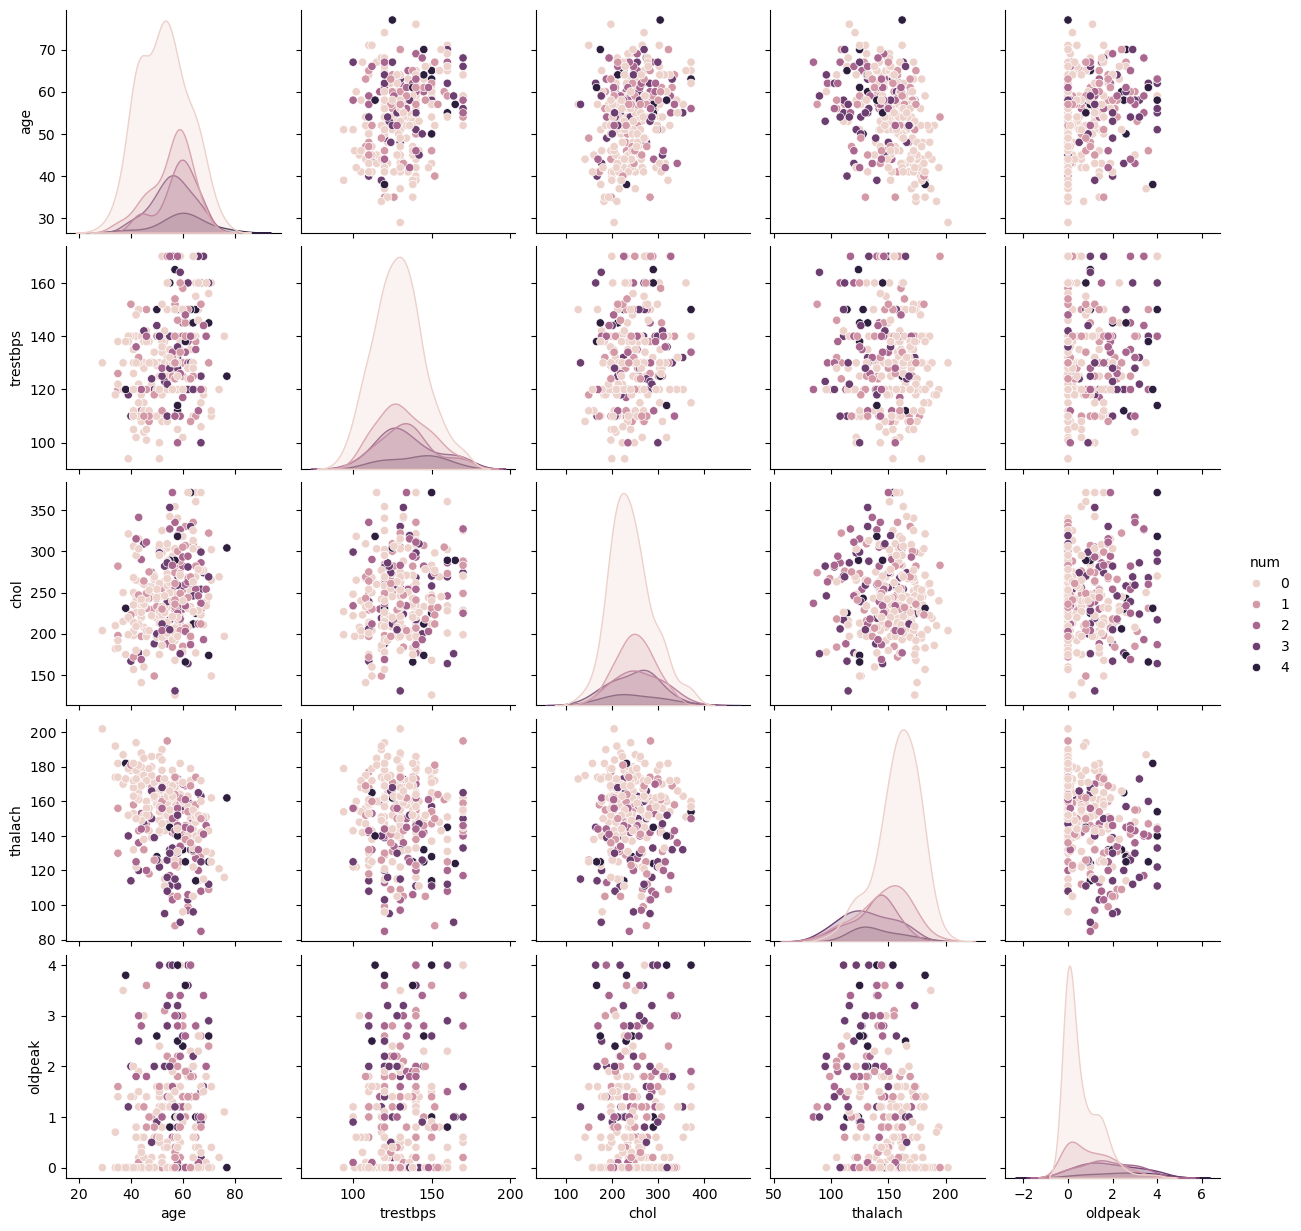

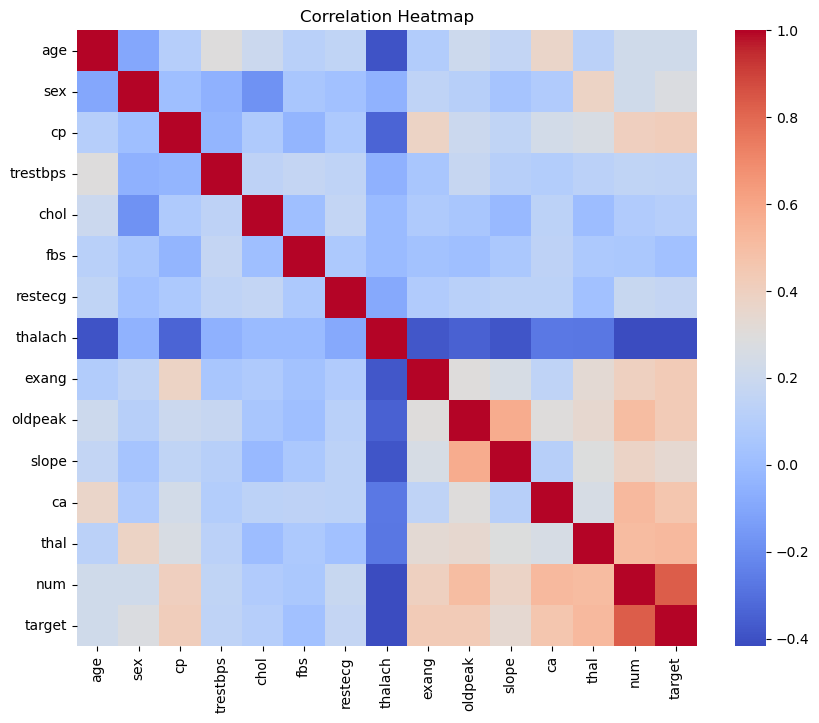

Hopkins Statistic: 0.6812


In [15]:
# ------------------------------------------------------------
# Step 3.3 Applied EDA: distributions, relationships, clustering tendency
# ------------------------------------------------------------
# ------------------------------------------------------------
# 3.3.1 Distributions
# ------------------------------------------------------------
#
X_scaled[num_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3.3.2 Relationships (pairplot subset)  #target == num
# ------------------------------------------------------------
# 
sns.pairplot(df[['age','trestbps','chol','thalach','oldpeak','num']],
             hue='num')
plt.show()

# ------------------------------------------------------------
# 3.3.3 Correlation matrix
# ------------------------------------------------------------
# 
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------------------------
# 3.3.4 Clustering tendency (Hopkins statistic – simple implementation)
# ------------------------------------------------------------
# 
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

def hopkins_statistic(X, sample_size=None, random_state=42):
    """
    Calculate Hopkins statistic.

    Interpretation:
    H ≈ 0.5  -> random data
    H < 0.5  -> clustering tendency
    H > 0.5  -> more regular/uniform structure
    """

    # Scale to [0,1]
    X_scaled = MinMaxScaler().fit_transform(X)

    n, d = X_scaled.shape

    if sample_size is None:
        sample_size = int(0.1 * n)

    rng = np.random.default_rng(random_state)

    # Random sample from dataset
    sample_idx = rng.choice(n, sample_size, replace=False)
    X_sample = X_scaled[sample_idx]

    # Random points from the feature space
    X_random = rng.uniform(
        np.min(X_scaled, axis=0),
        np.max(X_scaled, axis=0),
        (sample_size, d)
    )

    nbrs = NearestNeighbors(n_neighbors=2)
    nbrs.fit(X_scaled)

    # Distance from random points to nearest real point
    u_dist, _ = nbrs.kneighbors(X_random, n_neighbors=1)
    u_dist = u_dist.flatten()

    # Distance from sampled points to nearest OTHER real point
    w_dist, _ = nbrs.kneighbors(X_sample, n_neighbors=2)
    w_dist = w_dist[:, 1]  # Ignore self-neighbor

    H = np.sum(u_dist) / (np.sum(u_dist) + np.sum(w_dist))

    return H
#Note: Hopkins on all features instead of the selected 8 features

#print(X_scaled.shape)

H = hopkins_statistic(X_scaled)  #Hopkins on all features instead of the selected 8 features
print(f"Hopkins Statistic: {H:.4f}")

In [16]:
#print(X_scaled.shape)

H = hopkins_statistic(X_scaled)  #Hopkins on all features instead of the selected 8 features
print(f"Hopkins Statistic: {H:.4f}")

Hopkins Statistic: 0.6812


thal          0.136748
cp            0.109224
ca            0.098915
thalach       0.098848
risk_index    0.087420
oldpeak       0.084439
age           0.074864
chol          0.069623
trestbps      0.063371
exang         0.048263
slope         0.040433
sex           0.036509
age_bin       0.023394
restecg       0.019621
fbs           0.008331
dtype: float64


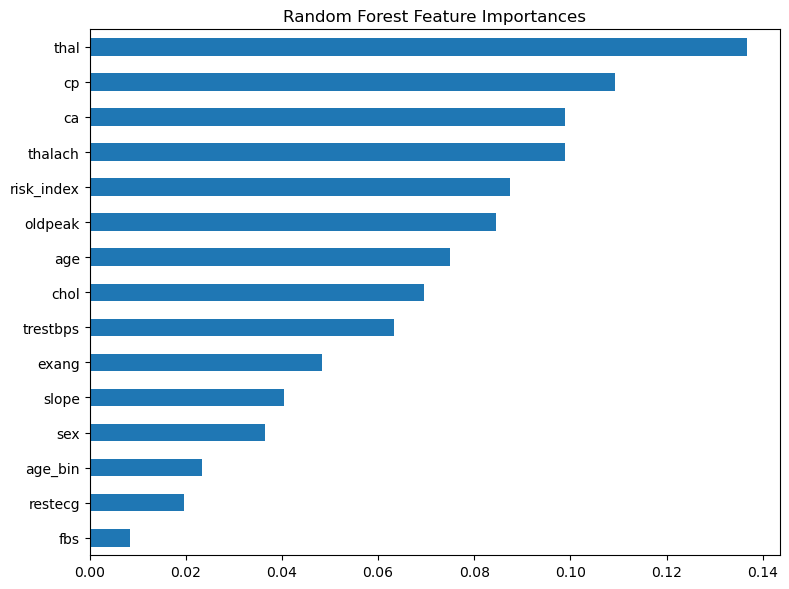

In [18]:
# ------------------------------------------------------------
# Step 3.4. Feature importance & explainability: SHAP, LIME, or model-based importances
# ------------------------------------------------------------
# ------------------------------------------------------------
# Step 3.4 Feature importance & explainability (Random Forest + SHAP)
# ------------------------------------------------------------
#
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
) 

# 3.4.1 Model-based feature importance
rf = RandomForestClassifier(n_estimators=200,
                            random_state=42,
                            class_weight='balanced')
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_scaled.columns)
print(importances.sort_values(ascending=False))

plt.figure(figsize=(8,6))
importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()



SHAP shape: (61, 15)
X_test shape: (61, 15)


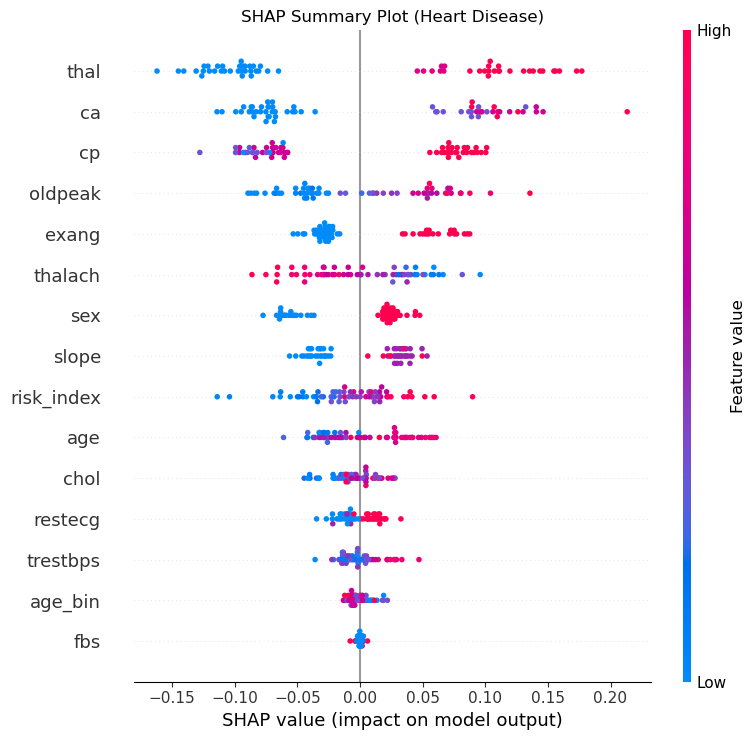

       Feature  MeanAbsSHAP
12        thal     0.106983
11          ca     0.089398
2           cp     0.078104
9      oldpeak     0.051131
8        exang     0.040044
7      thalach     0.037003
1          sex     0.035635
10       slope     0.033912
14  risk_index     0.028650
0          age     0.027830
4         chol     0.014621
6      restecg     0.012211
3     trestbps     0.011488
13     age_bin     0.006775
5          fbs     0.001429
          age       sex        cp  trestbps      chol       fbs   restecg  \
219  0.055667  0.023964  0.055776 -0.016802  0.004732  0.001420  0.014867   
271  0.003243  0.030003  0.093479  0.033407 -0.003110  0.001667  0.010959   
89  -0.035989 -0.063637 -0.064939 -0.008041 -0.003602 -0.002467  0.005372   
101 -0.032657  0.018515 -0.072209 -0.008955 -0.017787  0.000297  0.008722   
67  -0.032147  0.021727 -0.096291  0.021967  0.028000  0.002429  0.006654   

      thalach     exang   oldpeak     slope        ca      thal   age_bin  \
219 -0.06650

In [19]:
# SHAP explainability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Extract Heart Disease class (Class 1)
sv = shap_values[:, :, 1]

# Verify shapes
print("SHAP shape:", sv.shape)
print("X_test shape:", X_test.shape)

# SHAP summary plot
shap.summary_plot(
    sv,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot (Heart Disease)")
plt.tight_layout()
plt.show()

# Create SHAP table
shap_df = pd.DataFrame(
    sv,
    columns=X_test.columns,
    index=X_test.index
)

# Mean SHAP importance
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": np.abs(sv).mean(axis=0)
}).sort_values(
    "MeanAbsSHAP",
    ascending=False
)

print(importance)

importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

shap_df.to_csv(
    "shap_values.csv"
)


# Print SHAP values
shap_df = pd.DataFrame(
    sv,
    columns=X_test.columns,
    index=X_test.index
)

print(shap_df.head())

In [20]:

# 3.5 Feature selection (Filter method: SelectKBest)
# Use ANOVA F-test for classification

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)
selector.fit(X_scaled, y)

scores = pd.Series(selector.scores_, index=X_scaled.columns)
print("SelectKBest scores:\n", scores.sort_values(ascending=False))

selected_features = scores.sort_values(ascending=False).head(8).index.tolist()
print("Selected features:", selected_features)

X_selected = X_scaled[selected_features]

SelectKBest scores:
 thal          112.770163
ca             80.800610
exang          69.020891
oldpeak        68.400247
thalach        63.587697
cp             62.423779
slope          39.138194
risk_index     38.347541
sex            24.978872
age            15.769637
age_bin        10.809440
restecg         8.871394
trestbps        6.462598
chol            3.284557
fbs             0.192237
dtype: float64
Selected features: ['thal', 'ca', 'exang', 'oldpeak', 'thalach', 'cp', 'slope', 'risk_index']


Explained variance ratio: [0.98185574 0.00635818]


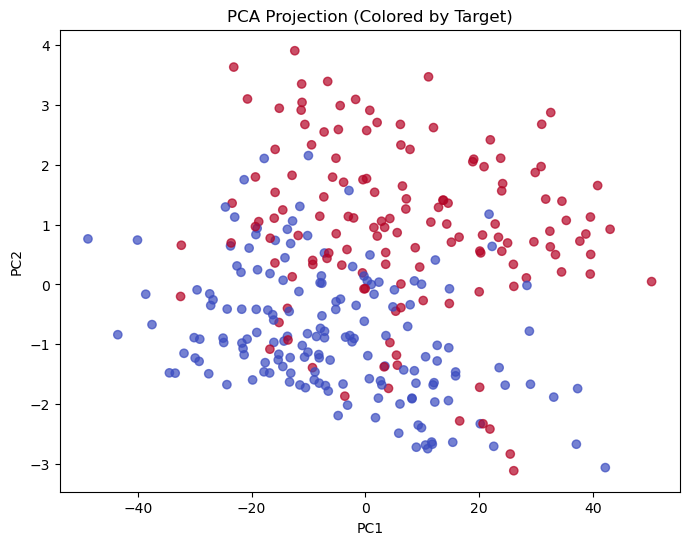

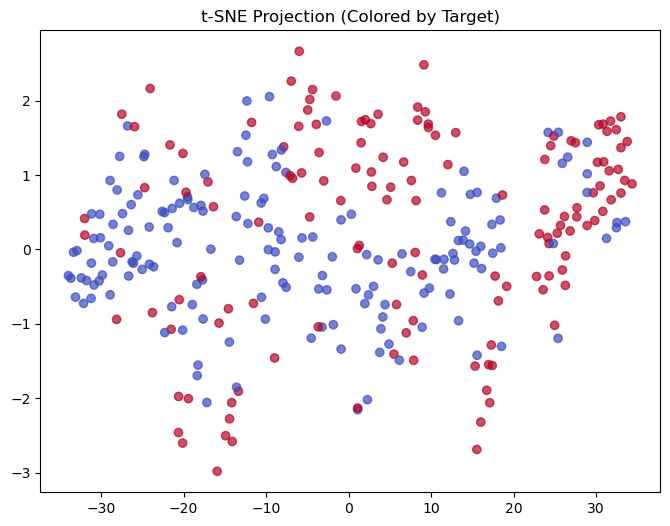

In [21]:
# 3.6 Dimensionality reduction: PCA (+ optional t-SNE/UMAP)
# 3.6.1 PCA on selected features
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_selected)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Colored by Target)")
plt.show()

# 3.6.2 Optional: t-SNE for visualization
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_selected)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE Projection (Colored by Target)")
plt.show()


In [22]:
!pip3 install joblib
import os
import joblib

# Ensure folder exists
os.makedirs("models", exist_ok=True)

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "2"